In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import TensorDataset, DataLoader

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':         ['Nimbus Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size':         10.5,
    'axes.titlesize':    11.5,
    'axes.labelsize':    11,
    'axes.linewidth':    0.8,
    'axes.edgecolor':    'black',
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  4.5,
    'ytick.major.size':  4.5,
    'figure.dpi':        130,
    'savefig.dpi':       300,
    'legend.frameon':    True,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#aaaaaa',
    'legend.fancybox':   False,
})

HIGH_RISK_COLOR = '#C73E1D'
LOW_RISK_COLOR  = '#2E86AB'
ATTACK_COLOR    = '#C73E1D'
DEFENSE_COLOR   = '#3FA796'
NOISE_COLOR     = '#7B3294'
TRUE_COLOR      = '#444444'
FROZEN_COLOR    = '#888888'
GRID_COLOR      = '#999999'

def _grid(ax, axis='both'):
    if axis in ('x', 'both'):
        ax.xaxis.grid(True, linestyle='--', linewidth=0.45,
                      alpha=0.45, color=GRID_COLOR)
    if axis in ('y', 'both'):
        ax.yaxis.grid(True, linestyle='--', linewidth=0.45,
                      alpha=0.45, color=GRID_COLOR)
    ax.set_axisbelow(True)

def _annotate(ax, text, xy, xytext, color='#222222', face='#FFF5F0',
              edge='#CC7777', rad=-0.2):
    ax.annotate(
        text, xy=xy, xytext=xytext, textcoords='axes fraction',
        fontsize=9.5, ha='right', va='top', color=color,
        bbox=dict(boxstyle='round,pad=0.45', facecolor=face,
                  edgecolor=edge, linewidth=0.8, alpha=0.95),
        arrowprops=dict(arrowstyle='->', color=edge, lw=1.0,
                        connectionstyle=f'arc3,rad={rad}'))

torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Synthetic health dataset
N, N_FEAT = 2000, 4
X_risk   = (np.random.randn(N//2, N_FEAT)
             + np.array([1.5, 1.2, 1.0, 1.8])).astype(np.float32)
X_norisk = (np.random.randn(N//2, N_FEAT)
             + np.array([-1.5, -1.2, -1.0, -1.8])).astype(np.float32)
X = np.vstack([X_risk, X_norisk])
y = np.concatenate([np.ones(N//2), np.zeros(N//2)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)
scaler   = StandardScaler().fit(X_train)
X_train  = scaler.transform(X_train).astype(np.float32)
X_test   = scaler.transform(X_test).astype(np.float32)

X_tr = torch.tensor(X_train); y_tr = torch.tensor(y_train, dtype=torch.float32)
X_te = torch.tensor(X_test);  y_te = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}   Features: {N_FEAT}')


Using device: cuda
Train: 1,000   Test: 1,000   Features: 4


In [2]:
class RiskMLP(nn.Module):
    def __init__(self, n_feat=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).squeeze(-1)

criterion  = nn.BCELoss()
target_model = RiskMLP().to(device)
opt          = torch.optim.Adam(target_model.parameters(), lr=0.001)

for epoch in range(100):
    target_model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt.zero_grad(); criterion(target_model(X_batch), y_batch).backward()
        opt.step()

target_model.eval()
with torch.no_grad():
    tr_acc = ((target_model(X_tr.to(device)) >= 0.5).float()
               == y_tr.to(device)).float().mean().item()
    te_acc = ((target_model(X_te.to(device)) >= 0.5).float()
               == y_te.to(device)).float().mean().item()
print(f'Train acc: {tr_acc*100:.1f}%  |  Test acc: {te_acc*100:.1f}%')
print(f'Gap: {(tr_acc-te_acc)*100:.1f} pp')

Train acc: 100.0%  |  Test acc: 99.8%
Gap: 0.2 pp


In [3]:
def invert_tabular(model, target_class=1, n_steps=1000,
                   lr=0.1, n_feat=4):
    """Recover the prototypical feature vector for target_class via
    gradient ascent on model confidence."""
    model.eval()
    x_inv = torch.randn(1, n_feat, device=device) * 0.1
    x_inv.requires_grad_(True)
    optimizer = torch.optim.Adam([x_inv], lr=lr)
    history   = []

    for step in range(n_steps):
        optimizer.zero_grad()
        conf = model(x_inv)
        target_conf = conf.item() if target_class == 1 else (1.0 - conf.item())
        history.append(target_conf)
        if target_class == 1:
            loss = -torch.log(conf + 1e-8)
        else:
            loss = -torch.log(1 - conf + 1e-8)
        loss.backward()
        optimizer.step()

    return x_inv.detach().cpu().numpy().squeeze(), history

torch.manual_seed(0)
x_inv_risk, history_risk = invert_tabular(target_model, target_class=1)
torch.manual_seed(0)
x_inv_norisk, history_norisk = invert_tabular(target_model, target_class=0)

# Compare against class means in standardized space (x_inv lives there).
true_risk_std   = scaler.transform(np.array([[ 1.5,  1.2,  1.0,  1.8]]))[0]
true_norisk_std = scaler.transform(np.array([[-1.5, -1.2, -1.0, -1.8]]))[0]

print('Reconstructed HIGH-RISK feature vector (standardized space):')
feat_names = ['Age', 'Blood Pressure', 'Cholesterol', 'Glucose']
for i, (name, val) in enumerate(zip(feat_names, x_inv_risk)):
    print(f'  {name:<18}: {val:>8.4f}  (true class-1 mean ~{true_risk_std[i]:+.4f})')

print('\nReconstructed LOW-RISK feature vector (standardized space):')
for i, (name, val) in enumerate(zip(feat_names, x_inv_norisk)):
    print(f'  {name:<18}: {val:>8.4f}  (true class-0 mean ~{true_norisk_std[i]:+.4f})')

target_model.eval()
with torch.no_grad():
    rec1 = torch.tensor(x_inv_risk,     dtype=torch.float32, device=device).unsqueeze(0)
    rec0 = torch.tensor(x_inv_norisk,   dtype=torch.float32, device=device).unsqueeze(0)
    tm1  = torch.tensor(true_risk_std,  dtype=torch.float32, device=device).unsqueeze(0)
    tm0  = torch.tensor(true_norisk_std,dtype=torch.float32, device=device).unsqueeze(0)
    print(f'\nModel confidence at the RECOVERED class-1 point : {target_model(rec1).item():.6f}')
    print(f'Model confidence at the TRUE class-1 mean       : {target_model(tm1).item():.6f}')
    print(f'Model confidence at the RECOVERED class-0 point : {1 - target_model(rec0).item():.6f}')
    print(f'Model confidence at the TRUE class-0 mean       : {1 - target_model(tm0).item():.6f}')


Reconstructed HIGH-RISK feature vector (standardized space):
  Age               :   0.5835  (true class-1 mean ~+0.8093)
  Blood Pressure    :   0.6308  (true class-1 mean ~+0.7872)
  Cholesterol       :   0.4227  (true class-1 mean ~+0.7312)
  Glucose           :   0.6883  (true class-1 mean ~+0.8457)

Reconstructed LOW-RISK feature vector (standardized space):
  Age               :  -0.6957  (true class-0 mean ~-0.8615)
  Blood Pressure    :  -0.6464  (true class-0 mean ~-0.7206)
  Cholesterol       :  -0.8688  (true class-0 mean ~-0.6715)
  Glucose           :  -0.5893  (true class-0 mean ~-0.8458)

Model confidence at the RECOVERED class-1 point : 1.000000
Model confidence at the TRUE class-1 mean       : 1.000000
Model confidence at the RECOVERED class-0 point : 1.000000
Model confidence at the TRUE class-0 mean       : 1.000000


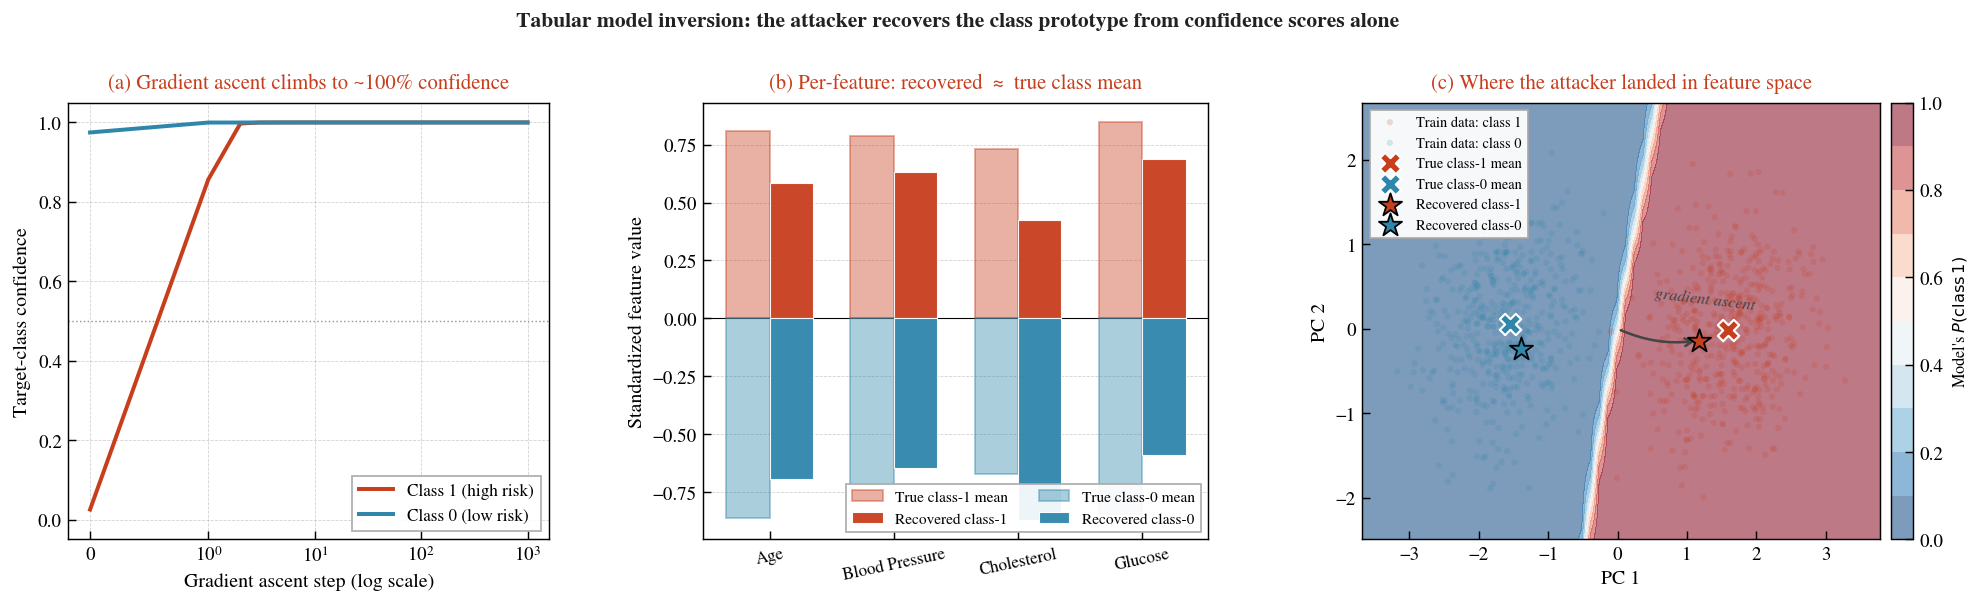

Reconstruction MSE -- high risk patient : 0.048858
Reconstruction MSE -- low risk patient  : 0.034436


In [4]:
true_risk_mean   = scaler.transform(np.array([[ 1.5,  1.2,  1.0,  1.8]]))[0]
true_norisk_mean = scaler.transform(np.array([[-1.5, -1.2, -1.0, -1.8]]))[0]

pca = PCA(n_components=2).fit(X_train)
def to2d(v): return pca.transform(np.atleast_2d(v))[0]

X_pca         = pca.transform(X_train)
risk_mean_2d  = to2d(true_risk_mean)
norisk_2d     = to2d(true_norisk_mean)
rec_risk_2d   = to2d(x_inv_risk)
rec_norisk_2d = to2d(x_inv_norisk)

g_lo = X_pca.min(0) - 0.5
g_hi = X_pca.max(0) + 0.5
gx, gy = np.meshgrid(np.linspace(g_lo[0], g_hi[0], 60),
                     np.linspace(g_lo[1], g_hi[1], 60))
grid_pca = np.column_stack([gx.ravel(), gy.ravel()])
grid_orig = pca.inverse_transform(grid_pca)
with torch.no_grad():
    target_model.eval()
    conf_grid = target_model(torch.tensor(grid_orig, dtype=torch.float32, device=device)).cpu().numpy()
conf_grid = conf_grid.reshape(gx.shape)

fig = plt.figure(figsize=(15.2, 4.8))
gs  = GridSpec(1, 3, width_ratios=[1.0, 1.05, 1.15],
               left=0.05, right=0.985, top=0.86, bottom=0.16, wspace=0.30)

ax = fig.add_subplot(gs[0, 0])
ax.plot(history_risk,   color=HIGH_RISK_COLOR, lw=2.2, label='Class 1 (high risk)', zorder=3)
ax.plot(history_norisk, color=LOW_RISK_COLOR,  lw=2.2, label='Class 0 (low risk)',  zorder=3)
ax.set_xscale('symlog', linthresh=1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Gradient ascent step (log scale)')
ax.set_ylabel('Target-class confidence')
ax.set_title('(a) Gradient ascent climbs to ~100% confidence',
             pad=8, color=HIGH_RISK_COLOR)
_grid(ax, 'both')
ax.legend(loc='lower right', fontsize=9.5)
ax.axhline(0.5, color=GRID_COLOR, ls=':', lw=0.8, zorder=1)

ax = fig.add_subplot(gs[0, 1])
xs = np.arange(N_FEAT); w = 0.35
ax.bar(xs - w/2, true_risk_mean,  w, color=HIGH_RISK_COLOR, alpha=0.40,
       edgecolor=HIGH_RISK_COLOR, lw=1.1, label='True class-1 mean',  zorder=3)
ax.bar(xs + w/2, x_inv_risk,      w, color=HIGH_RISK_COLOR, alpha=0.95,
       edgecolor='white', lw=0.6, label='Recovered class-1', zorder=3)
ax.bar(xs - w/2, true_norisk_mean, w, color=LOW_RISK_COLOR,  alpha=0.40,
       edgecolor=LOW_RISK_COLOR, lw=1.1, label='True class-0 mean',  zorder=3)
ax.bar(xs + w/2, x_inv_norisk,    w, color=LOW_RISK_COLOR,  alpha=0.95,
       edgecolor='white', lw=0.6, label='Recovered class-0', zorder=3)
ax.axhline(0, color='black', lw=0.6, zorder=2)
ax.set_xticks(xs)
ax.set_xticklabels(feat_names, rotation=12, fontsize=9.5)
ax.set_ylabel('Standardized feature value')
ax.set_title('(b) Per-feature: recovered ≈ true class mean',
             pad=8, color=HIGH_RISK_COLOR)
ax.legend(loc='lower right', fontsize=8.5, ncol=2)
_grid(ax, 'y')

ax = fig.add_subplot(gs[0, 2])
cs = ax.contourf(gx, gy, conf_grid, levels=np.linspace(0, 1, 11),
                 cmap='RdBu_r', alpha=0.55, zorder=1)
mask_risk = y_train > 0.5
ax.scatter(X_pca[mask_risk, 0], X_pca[mask_risk, 1], s=12,
           color=HIGH_RISK_COLOR, alpha=0.18, edgecolors='none', zorder=2,
           label='Train data: class 1')
ax.scatter(X_pca[~mask_risk, 0], X_pca[~mask_risk, 1], s=12,
           color=LOW_RISK_COLOR,  alpha=0.18, edgecolors='none', zorder=2,
           label='Train data: class 0')

ax.scatter(*risk_mean_2d, marker='X', s=140, color=HIGH_RISK_COLOR,
           edgecolor='white', lw=1.2, zorder=5, label='True class-1 mean')
ax.scatter(*norisk_2d,    marker='X', s=140, color=LOW_RISK_COLOR,
           edgecolor='white', lw=1.2, zorder=5, label='True class-0 mean')
ax.scatter(*rec_risk_2d,   marker='*', s=180, color=HIGH_RISK_COLOR,
           edgecolor='black', lw=1.0, zorder=6, label='Recovered class-1')
ax.scatter(*rec_norisk_2d, marker='*', s=180, color=LOW_RISK_COLOR,
           edgecolor='black', lw=1.0, zorder=6, label='Recovered class-0')

ax.annotate('', xy=rec_risk_2d, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.4,
                            connectionstyle='arc3,rad=0.15'),
            zorder=4)
ax.text(rec_risk_2d[0]*0.45, rec_risk_2d[1]*0.45 + 0.3,
        'gradient ascent', fontsize=9, color='#444444', style='italic',
        rotation=np.degrees(np.arctan2(rec_risk_2d[1], rec_risk_2d[0])))

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('(c) Where the attacker landed in feature space',
             pad=8, color=HIGH_RISK_COLOR)
ax.legend(loc='upper left', fontsize=8.0, ncol=1, framealpha=0.94)
cb = plt.colorbar(cs, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("Model's $P(\\mathrm{class\\,1})$", fontsize=9)
cb.outline.set_linewidth(0.8)

plt.suptitle("Tabular model inversion: the attacker recovers the class prototype "
             "from confidence scores alone", fontsize=12, y=1.005,
             color='#222222', fontweight='bold')
plt.show()

mse_risk   = float(np.mean((x_inv_risk   - true_risk_mean)  **2))
mse_norisk = float(np.mean((x_inv_norisk - true_norisk_mean)**2))
print(f'Reconstruction MSE -- high risk patient : {mse_risk:.6f}')
print(f'Reconstruction MSE -- low risk patient  : {mse_norisk:.6f}')


In [5]:
import torchvision, torchvision.transforms as transforms

transform   = transforms.ToTensor()
trainset    = torchvision.datasets.MNIST('./data', True,
                                          download=True, transform=transform)
testset     = torchvision.datasets.MNIST('./data', False, transform=transform)
mnist_train = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
mnist_test  = torch.utils.data.DataLoader(testset,  batch_size=256, shuffle=False)

class DigitCNN(nn.Module):
    """CNN classifier for MNIST with full softmax output."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 64*7*7)
        return F.softmax(self.fc2(F.relu(self.fc1(x))), dim=1)

digit_model = DigitCNN().to(device)

# Train once and cache to disk so the inversion attacks below are reproducible
# across machines (cuDNN training is not bit-exact across different GPUs).
_CKPT = './data/digit_model_seed42.pt'
if os.path.exists(_CKPT):
    digit_model.load_state_dict(torch.load(_CKPT, map_location=device, weights_only=True))
    print(f'Loaded cached MNIST model from {_CKPT}.')
else:
    opt     = torch.optim.Adam(digit_model.parameters(), lr=0.001)
    ce_loss = nn.CrossEntropyLoss()
    print('Training MNIST digit classifier...')
    for epoch in range(5):
        digit_model.train()
        for imgs, lbls in mnist_train:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad(); ce_loss(digit_model(imgs), lbls).backward(); opt.step()
    torch.save(digit_model.state_dict(), _CKPT)
    print(f'Trained and saved MNIST model to {_CKPT}.')

digit_model.eval()
correct = 0
with torch.no_grad():
    for imgs, lbls in mnist_test:
        correct += (digit_model(imgs.to(device)).argmax(1)
                    == lbls.to(device)).sum().item()
print(f'Test accuracy: {correct/len(testset)*100:.2f}%')


Loaded cached MNIST model from ./data/digit_model_seed42.pt.
Test accuracy: 98.55%


Running model inversion for all 10 digit classes...
  Class 0 done.
  Class 1 done.
  Class 2 done.
  Class 3 done.
  Class 4 done.
  Class 5 done.
  Class 6 done.
  Class 7 done.
  Class 8 done.
  Class 9 done.


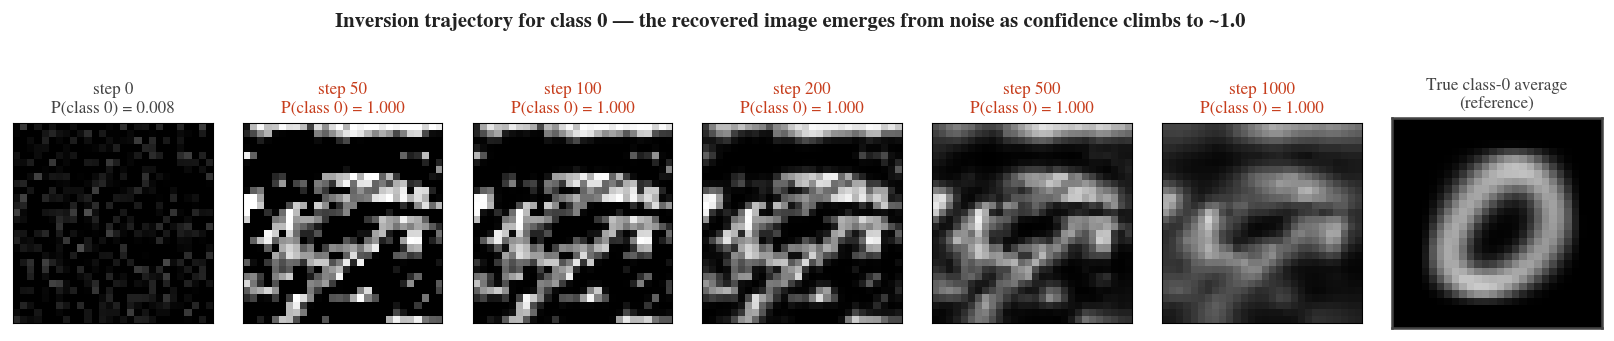

In [6]:
def total_variation(x):
    """Sum of squared differences between neighbouring pixels."""
    return ((x[..., 1:, :] - x[..., :-1, :]) ** 2).mean() \
         + ((x[..., :, 1:] - x[..., :, :-1]) ** 2).mean()

def invert_image(model, target_class, n_steps=1000, lr=0.1,
                 tv_lambda=0.05, img_shape=(1, 1, 28, 28),
                 snapshot_steps=None):
    """Reconstruct the image the model most confidently classifies as
    target_class, using gradient ascent with a TV smoothness prior."""
    model.eval()
    x_inv = torch.randn(*img_shape, device=device) * 0.1
    x_inv.requires_grad_(True)
    optimizer = torch.optim.Adam([x_inv], lr=lr)
    snapshots = {} if snapshot_steps is None else {0: x_inv.detach().cpu().squeeze().numpy().copy()}

    for step in range(n_steps):
        optimizer.zero_grad()
        probs = model(x_inv)
        loss  = -torch.log(probs[0, target_class] + 1e-8) \
              + tv_lambda * total_variation(x_inv)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            x_inv.clamp_(0, 1)
        if snapshot_steps and (step + 1) in snapshot_steps:
            snapshots[step + 1] = x_inv.detach().cpu().squeeze().numpy().copy()

    final = x_inv.detach().cpu().squeeze().numpy()
    if snapshot_steps is None:
        return final
    return final, snapshots

print('Running model inversion for all 10 digit classes...')
inverted_digits = {}
for digit in range(10):
    torch.manual_seed(42)
    inverted_digits[digit] = invert_image(digit_model, target_class=digit)
    print(f'  Class {digit} done.')

torch.manual_seed(42)
TRAJ_STEPS = [50, 100, 200, 500, 1000]
_, traj = invert_image(digit_model, target_class=0,
                        snapshot_steps=TRAJ_STEPS)

digit_model.eval()
step_keys = sorted(traj.keys())
confs = []
with torch.no_grad():
    for s in step_keys:
        t = torch.tensor(traj[s], dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        confs.append(digit_model(t)[0, 0].item())

true_avg_0 = trainset.data[trainset.targets == 0].float().mean(0).numpy() / 255.0

fig = plt.figure(figsize=(13.0, 3.0))
gs  = GridSpec(1, len(step_keys) + 1, width_ratios=[1.0]*len(step_keys) + [1.05],
               left=0.04, right=0.98, top=0.78, bottom=0.04, wspace=0.15)

for i, s in enumerate(step_keys):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(traj[s], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'step {s}\nP(class 0) = {confs[i]:.3f}',
                 fontsize=9.5, color=HIGH_RISK_COLOR if confs[i] > 0.99 else '#444444')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_linewidth(0.6)

ax = fig.add_subplot(gs[0, -1])
ax.imshow(true_avg_0, cmap='gray', vmin=0, vmax=1)
ax.set_title('True class-0 average\n(reference)',
             fontsize=9.5, color=TRUE_COLOR)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_linewidth(1.4); spine.set_edgecolor(TRUE_COLOR)

plt.suptitle('Inversion trajectory for class 0 — '
             'the recovered image emerges from noise as confidence climbs to ~1.0',
             fontsize=11.5, y=0.95, color='#222222', fontweight='bold')
plt.show()


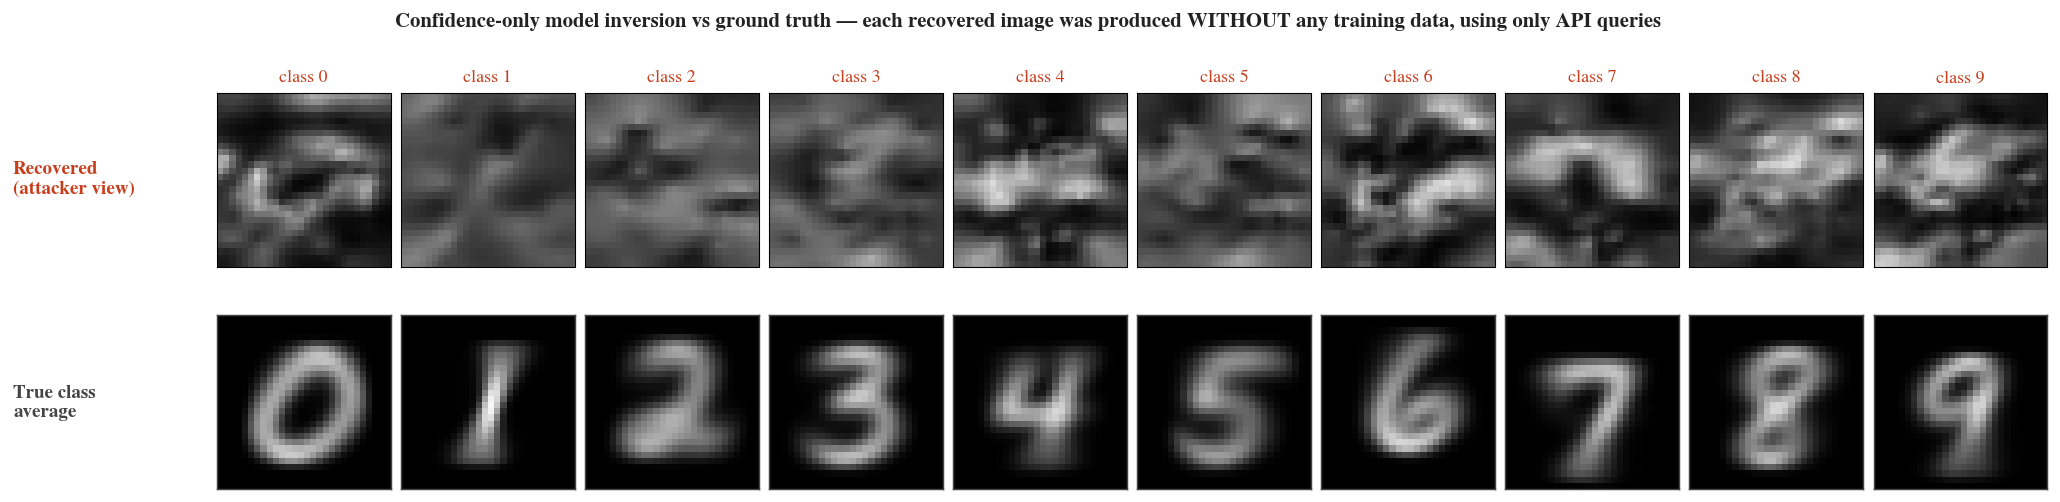

In [7]:
fig = plt.figure(figsize=(16.0, 4.0))
gs  = GridSpec(2, 10, left=0.11, right=0.99, top=0.83, bottom=0.04,
               wspace=0.06, hspace=0.18)

for digit in range(10):
    ax = fig.add_subplot(gs[0, digit])
    ax.imshow(inverted_digits[digit], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'class {digit}', fontsize=10, color=HIGH_RISK_COLOR)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_linewidth(0.6)

for digit in range(10):
    ax = fig.add_subplot(gs[1, digit])
    avg = trainset.data[trainset.targets == digit].float().mean(0).numpy() / 255.
    ax.imshow(avg, cmap='gray', vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.8); s.set_edgecolor(TRUE_COLOR)

fig.text(0.012, 0.65, 'Recovered\n(attacker view)', fontsize=10.5,
         color=HIGH_RISK_COLOR, fontweight='bold', va='center', ha='left')
fig.text(0.012, 0.22, 'True class\naverage', fontsize=10.5,
         color=TRUE_COLOR, fontweight='bold', va='center', ha='left')

plt.suptitle('Confidence-only model inversion vs ground truth — '
             'each recovered image was produced WITHOUT any training data, '
             'using only API queries',
             fontsize=11.5, y=0.97, color='#222222', fontweight='bold')
plt.show()


In [8]:
print(f'{"Class":>6}  {"MSE":>10}  {"Max conf at recovery":>22}')
print('-' * 45)

digit_model.eval()
mse_per_class = []
for digit in range(10):
    true_avg    = trainset.data[trainset.targets == digit].float().mean(0).numpy() / 255.0
    inv_img     = inverted_digits[digit]
    mse         = np.mean((inv_img - true_avg) ** 2)
    mse_per_class.append(mse)

    inv_tensor  = torch.tensor(inv_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        final_conf = digit_model(inv_tensor.to(device))[0, digit].item()

    print(f'  {digit:>3}    {mse:>10.6f}    {final_conf*100:>20.1f}%')

print(f'\nMean MSE across all classes: {np.mean(mse_per_class):.6f}')
print('Lower MSE = closer to true class prototype = more information leaked.')


 Class         MSE    Max conf at recovery
---------------------------------------------
    0      0.058944                   100.0%
    1      0.079869                   100.0%
    2      0.069664                   100.0%
    3      0.073574                   100.0%
    4      0.080116                   100.0%
    5      0.084994                   100.0%
    6      0.097152                   100.0%
    7      0.065632                   100.0%
    8      0.076620                   100.0%
    9      0.074712                   100.0%

Mean MSE across all classes: 0.076128
Lower MSE = closer to true class prototype = more information leaked.


Running label-only inversion for digit 0...


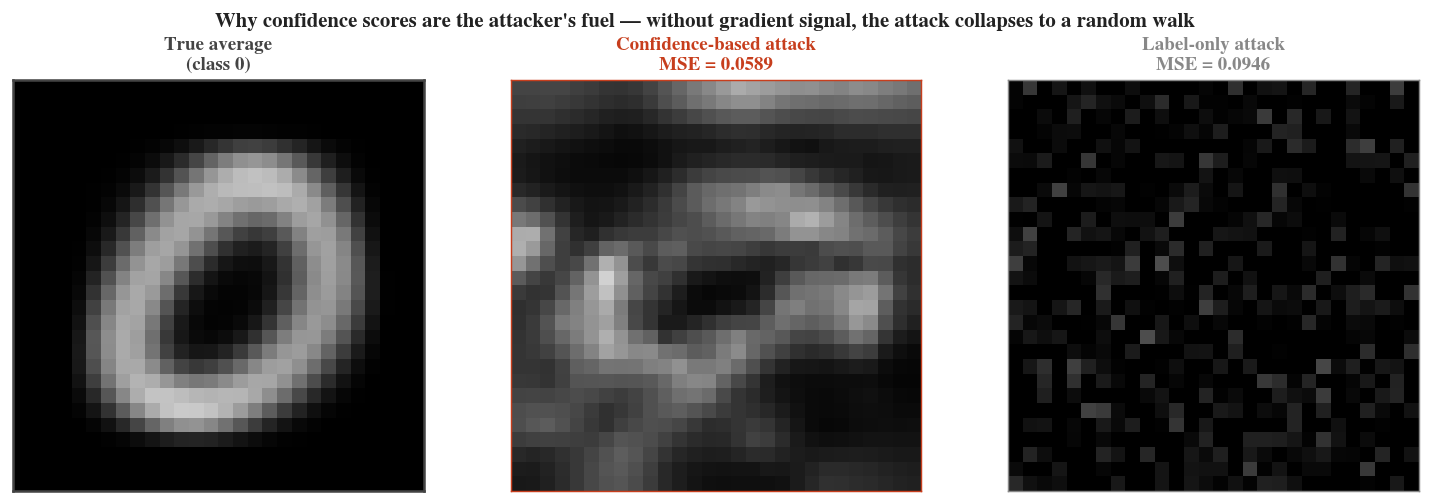

Confidence-based MSE : 0.058944
Label-only MSE       : 0.094635
Label-only / confidence-based MSE ratio: 1.61x


In [9]:
def invert_label_only(model, target_class, n_steps=1000, lr=0.1,
                      img_shape=(1, 1, 28, 28)):
    """Random-walk inversion: only the predicted label is observable, so
    no gradient signal is available."""
    model.eval()
    x_inv = torch.randn(*img_shape, device=device) * 0.1
    for step in range(n_steps):
        candidate = torch.clamp(x_inv + torch.randn_like(x_inv) * 0.05, 0, 1)
        with torch.no_grad():
            label = model(candidate.to(device)).argmax(1).item()
        if label == target_class:
            x_inv = candidate.detach()
    return x_inv.cpu().squeeze().numpy()

print('Running label-only inversion for digit 0...')
torch.manual_seed(42)
inv_label_only = invert_label_only(digit_model, target_class=0)
inv_full_conf  = inverted_digits[0]

true_avg = trainset.data[trainset.targets == 0].float().mean(0).numpy() / 255.0
mse_conf  = float(np.mean((inv_full_conf  - true_avg) ** 2))
mse_label = float(np.mean((inv_label_only - true_avg) ** 2))
ratio     = mse_label / mse_conf if mse_conf > 0 else float('inf')

fig = plt.figure(figsize=(11.5, 4.0))
gs  = GridSpec(1, 3, left=0.03, right=0.985, top=0.83, bottom=0.04, wspace=0.15)

panels = [
    ('True average\n(class 0)',                  true_avg,       TRUE_COLOR,    None),
    (f'Confidence-based attack\nMSE = {mse_conf:.4f}', inv_full_conf,  HIGH_RISK_COLOR, mse_conf),
    (f'Label-only attack\nMSE = {mse_label:.4f}',      inv_label_only, FROZEN_COLOR,    mse_label),
]
for j, (title, img, color, mse) in enumerate(panels):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10.5, color=color, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(1.4 if mse is None else 0.8); s.set_edgecolor(color)

plt.suptitle("Why confidence scores are the attacker's fuel — "
             "without gradient signal, the attack collapses to a random walk",
             fontsize=11.5, y=0.96, color='#222222', fontweight='bold')
plt.show()

print(f'Confidence-based MSE : {mse_conf:.6f}')
print(f'Label-only MSE       : {mse_label:.6f}')
print(f'Label-only / confidence-based MSE ratio: {ratio:.2f}x')


Inverting (suppression = none) ...
Inverting (suppression = round2) ...
Inverting (suppression = round1) ...
Inverting (suppression = top3) ...

Mode            WB MSE      BB MSE   BB / WB
--------------------------------------------------
none            0.0589      0.0857     1.45x
round2          0.0589      0.1041     1.77x
round1          0.0589      0.0776     1.32x
top3            0.0589      0.0776     1.32x


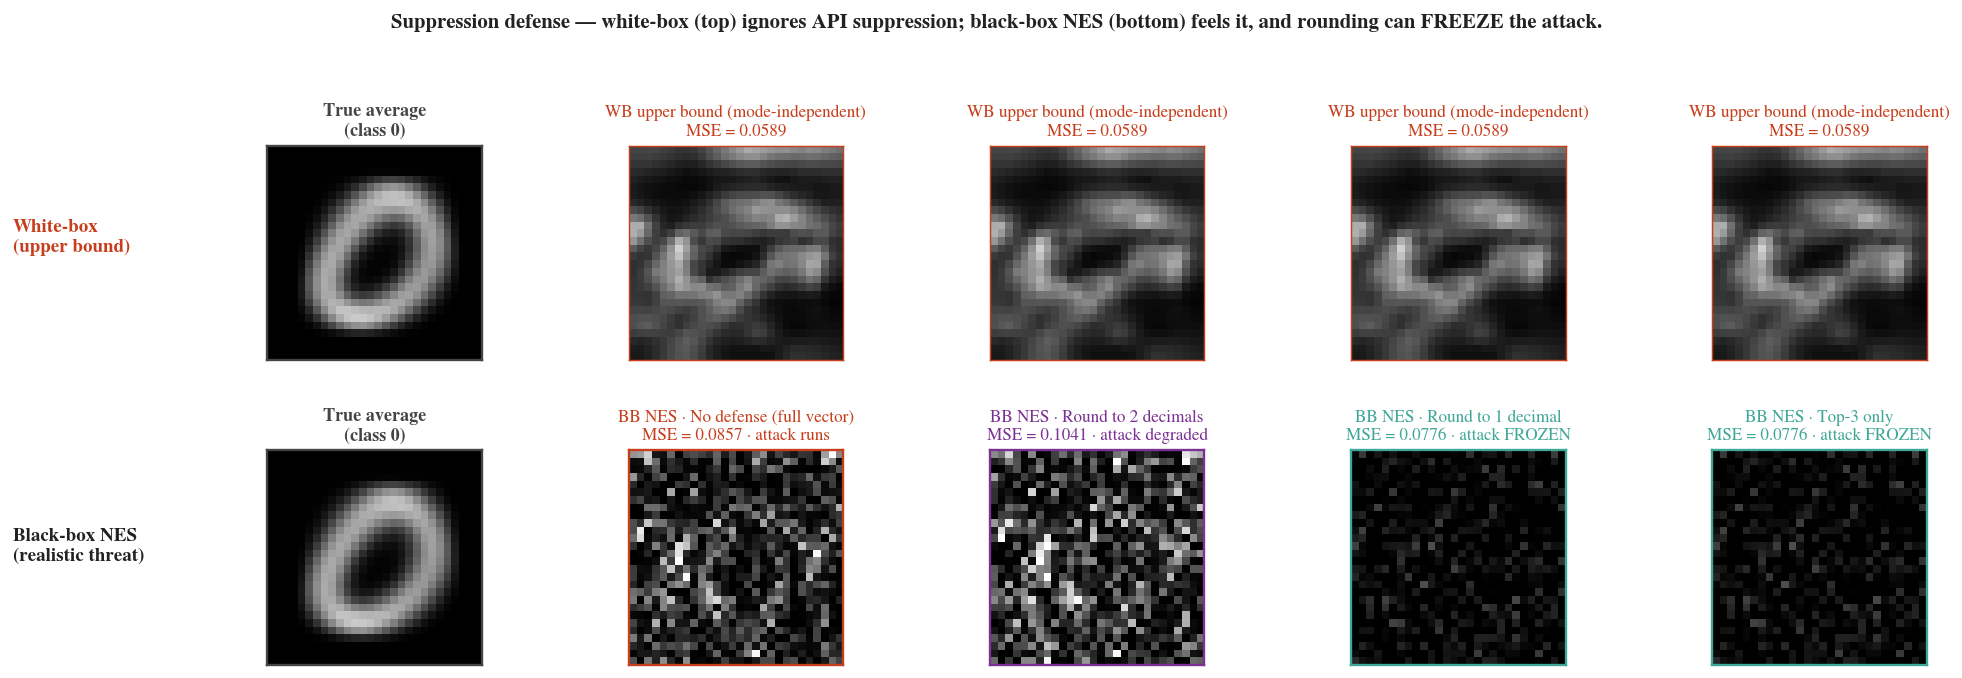


Frozen-attack baseline (random init vs true average): MSE = 0.0776
Any BB MSE near this number means the suppression killed the
gradient signal entirely and x_inv never moved.

Per-mode reading:
    none: BB MSE = 0.0857  ->  baseline (no defense)
  round2: BB MSE = 0.1041  ->  degraded (+21% vs none)
  round1: BB MSE = 0.0776  ->  FROZEN at init -- gradient signal blocked
    top3: BB MSE = 0.0776  ->  FROZEN at init -- gradient signal blocked


In [10]:
def apply_suppression(probs, mode):
    """Transform a probability vector into what the API actually returns."""
    if mode == 'none':
        return probs
    if mode == 'round2':
        return torch.round(probs * 100) / 100
    if mode == 'round1':
        return torch.round(probs * 10) / 10
    if mode == 'top3':
        vals, idx = probs.topk(3, dim=-1)
        out = torch.zeros_like(probs)
        out.scatter_(-1, idx, vals)
        return out
    raise ValueError(mode)


def invert_whitebox(model, target_class, n_steps=1000, lr=0.1,
                    tv_lambda=0.05, img_shape=(1, 1, 28, 28)):
    """Full gradient ascent with model weights (white-box upper bound)."""
    model.eval()
    x_inv = torch.randn(*img_shape, device=device) * 0.1
    x_inv.requires_grad_(True)
    optimizer = torch.optim.Adam([x_inv], lr=lr)
    for _ in range(n_steps):
        optimizer.zero_grad()
        probs = model(x_inv)
        loss  = -torch.log(probs[0, target_class] + 1e-8) \
              + tv_lambda * total_variation(x_inv)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            x_inv.clamp_(0, 1)
    return x_inv.detach().cpu().squeeze().numpy()


def invert_blackbox(model, target_class, suppression='none',
                    n_steps=600, lr=0.5, eps=0.05, n_samples=40,
                    img_shape=(1, 1, 28, 28)):
    """NES attacker that only sees apply_suppression(model(x))."""
    model.eval()
    x = torch.randn(*img_shape, device=device) * 0.1
    for _ in range(n_steps):
        U = torch.randn(n_samples, *img_shape, device=device)
        with torch.no_grad():
            x_plus  = (x + eps * U).clamp(0, 1)
            x_minus = (x - eps * U).clamp(0, 1)
            p_plus  = apply_suppression(model(x_plus.view(-1, *img_shape[1:])),  suppression)
            p_minus = apply_suppression(model(x_minus.view(-1, *img_shape[1:])), suppression)
            scale = (p_plus[:, target_class] - p_minus[:, target_class]).view(
                       -1, *([1] * len(img_shape)))
            grad  = (scale * U).mean(0) / (2 * eps)
            x = (x + lr * grad).clamp(0, 1)
    return x.cpu().squeeze().numpy()


true_avg = trainset.data[trainset.targets == 0].float().mean(0).numpy() / 255.0
target   = 0
modes    = ['none', 'round2', 'round1', 'top3']
titles   = {'none':   'No defense (full vector)',
            'round2': 'Round to 2 decimals',
            'round1': 'Round to 1 decimal',
            'top3':   'Top-3 only'}

wb_imgs, bb_imgs, wb_mse, bb_mse = {}, {}, {}, {}
for mode in modes:
    print(f'Inverting (suppression = {mode}) ...')
    torch.manual_seed(42)
    wb_imgs[mode] = invert_whitebox(digit_model, target)
    torch.manual_seed(42)
    bb_imgs[mode] = invert_blackbox(digit_model, target, mode)
    wb_mse[mode]  = np.mean((wb_imgs[mode] - true_avg) ** 2)
    bb_mse[mode]  = np.mean((bb_imgs[mode] - true_avg) ** 2)

print(f'\n{"Mode":<10}  {"WB MSE":>10}  {"BB MSE":>10}  {"BB / WB":>8}')
print('-' * 50)
for mode in modes:
    ratio = bb_mse[mode] / wb_mse[mode] if wb_mse[mode] > 0 else float('inf')
    print(f'{mode:<10}  {wb_mse[mode]:>10.4f}  {bb_mse[mode]:>10.4f}  {ratio:>7.2f}x')

# Frozen-attack baseline: MSE of the random init against the true class
# average (matches NES init exactly: scale first, then clamp).
torch.manual_seed(42)
_init_img   = (torch.randn(1, 1, 28, 28, device=device) * 0.1).clamp(0, 1)
_init_img_c = _init_img.cpu().squeeze().numpy()
_init_mse   = float(np.mean((_init_img_c - true_avg) ** 2))

fig = plt.figure(figsize=(15.5, 5.4))
gs  = GridSpec(2, 5, left=0.11, right=0.99, top=0.78, bottom=0.04,
               wspace=0.10, hspace=0.42)

for r in range(2):
    ax = fig.add_subplot(gs[r, 0])
    ax.imshow(true_avg, cmap='gray', vmin=0, vmax=1)
    ax.set_title('True average\n(class 0)', fontsize=10, color=TRUE_COLOR,
                 fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(1.3); s.set_edgecolor(TRUE_COLOR)

for i, mode in enumerate(modes):
    ax = fig.add_subplot(gs[0, i+1])
    ax.imshow(wb_imgs[mode], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'WB upper bound (mode-independent)\nMSE = {wb_mse[mode]:.4f}',
                 fontsize=9.5, color=ATTACK_COLOR)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.8); s.set_edgecolor(ATTACK_COLOR)

    ax = fig.add_subplot(gs[1, i+1])
    ax.imshow(bb_imgs[mode], cmap='gray', vmin=0, vmax=1)
    is_frozen = abs(bb_mse[mode] - _init_mse) < 0.005
    if is_frozen:
        frame_c = DEFENSE_COLOR
        annot = 'attack FROZEN'
    elif bb_mse[mode] > bb_mse['none'] * 1.05:
        frame_c = NOISE_COLOR
        annot = 'attack degraded'
    else:
        frame_c = ATTACK_COLOR
        annot = 'attack runs'
    ax.set_title(f'BB NES · {titles[mode]}\nMSE = {bb_mse[mode]:.4f} · {annot}',
                 fontsize=9.5, color=frame_c)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(1.3); s.set_edgecolor(frame_c)

fig.text(0.012, 0.65, 'White-box\n(upper bound)', fontsize=10.5,
         color=ATTACK_COLOR, fontweight='bold', va='center', ha='left')
fig.text(0.012, 0.21, 'Black-box NES\n(realistic threat)', fontsize=10.5,
         color='#222222', fontweight='bold', va='center', ha='left')

plt.suptitle(
    'Suppression defense — white-box (top) ignores API suppression; '
    'black-box NES (bottom) feels it, and rounding can FREEZE the attack.',
    fontsize=11.5, y=0.97, color='#222222', fontweight='bold')
plt.show()

print(f'\nFrozen-attack baseline (random init vs true average): MSE = {_init_mse:.4f}')
print('Any BB MSE near this number means the suppression killed the')
print('gradient signal entirely and x_inv never moved.')
print()
print('Per-mode reading:')
frozen = {m: abs(bb_mse[m] - _init_mse) < 0.005 for m in modes}
for m in modes:
    diff_pct = (bb_mse[m] / bb_mse['none'] - 1) * 100
    if m == 'none':
        tag = 'baseline (no defense)'
    elif frozen[m]:
        tag = 'FROZEN at init -- gradient signal blocked'
    elif diff_pct > 5:
        tag = f'degraded ({diff_pct:+.0f}% vs none)'
    elif diff_pct < -5:
        tag = f'MSE {diff_pct:+.0f}% vs none -- inspect figure'
    else:
        tag = 'runs (within ~5% of none)'
    print(f'  {m:>6}: BB MSE = {bb_mse[m]:.4f}  ->  {tag}')


   Sigma         MSE                  Interpretation
-------------------------------------------------------
    0.00    0.086110    No defense (attack succeeds)
    0.02    0.136469         Attack visibly degraded
    0.05    0.242009                   Attack broken
    0.10    0.268877                   Attack broken
    0.20    0.268035                   Attack broken
    0.50    0.284899                   Attack broken


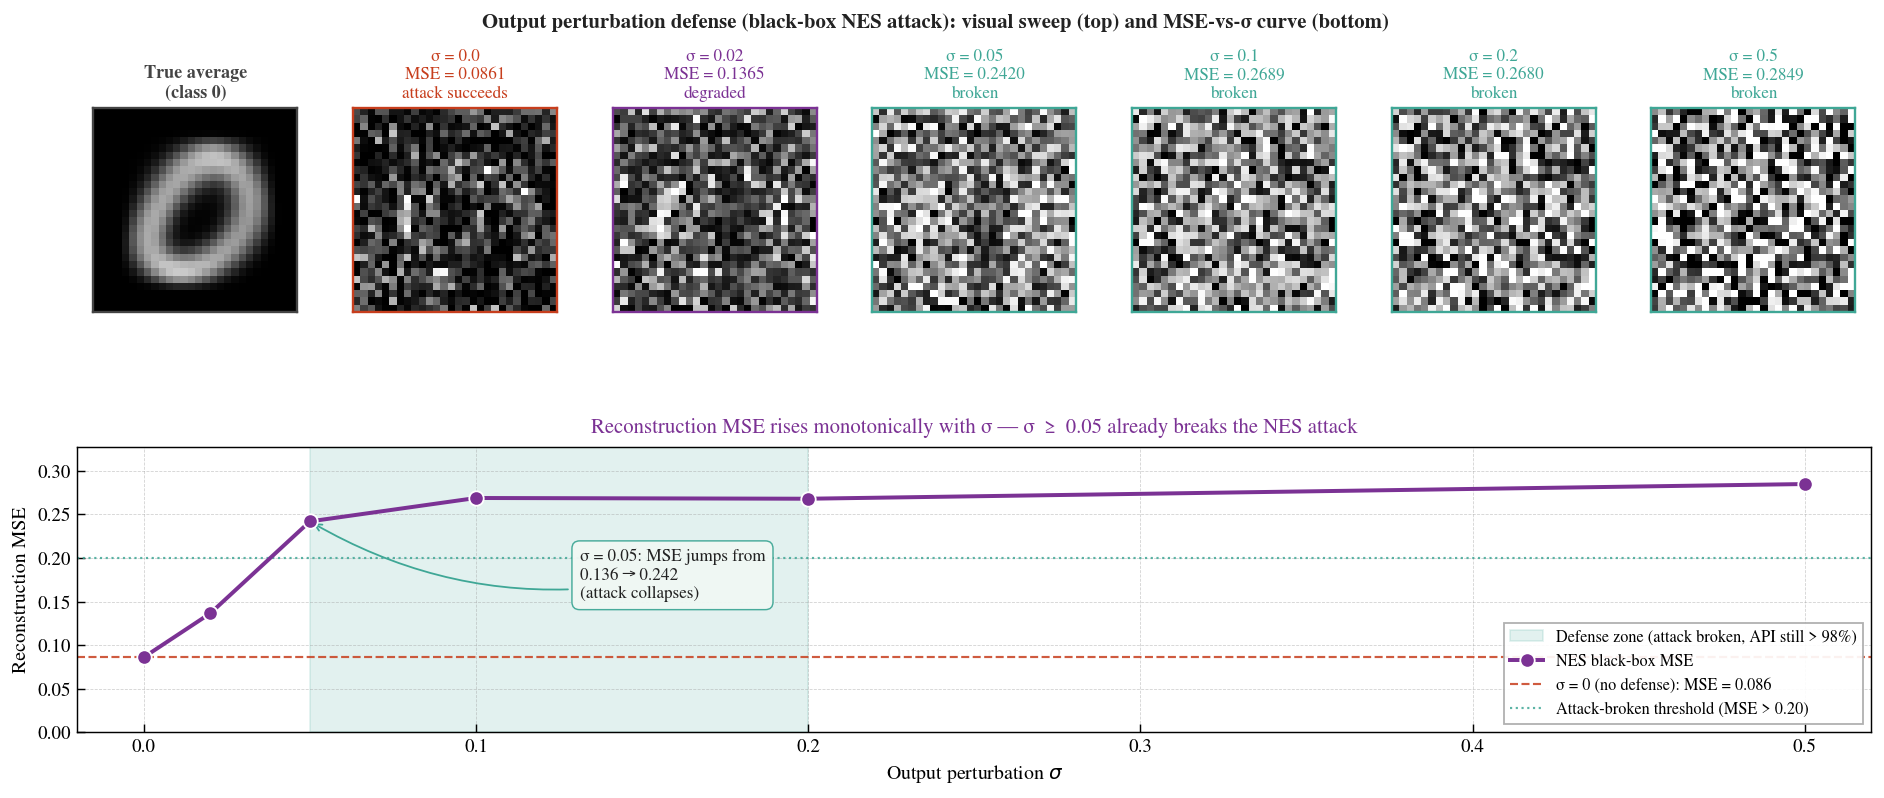

In [11]:
def invert_with_noise(model, target_class, sigma=0.05,
                      n_steps=600, lr=0.5, eps=0.05, n_samples=40,
                      img_shape=(1, 1, 28, 28)):
    """Black-box NES inversion under Gaussian output perturbation.

    The API adds N(0, sigma**2) noise to the confidence vector before
    returning it; the attacker estimates the gradient with NES (antithetic
    sampling): grad ~ E_u[(f(x+eps*u) - f(x-eps*u)) * u / (2*eps)].
    """
    model.eval()
    x = torch.randn(*img_shape, device=device) * 0.1

    for step in range(n_steps):
        U = torch.randn(n_samples, *img_shape, device=device)
        with torch.no_grad():
            x_plus  = (x + eps * U).clamp(0, 1)
            x_minus = (x - eps * U).clamp(0, 1)
            c_plus  = model(x_plus.view(-1, *img_shape[1:]))[:, target_class]
            c_minus = model(x_minus.view(-1, *img_shape[1:]))[:, target_class]
            c_plus  = (c_plus  + sigma * torch.randn_like(c_plus )).clamp(0, 1)
            c_minus = (c_minus + sigma * torch.randn_like(c_minus)).clamp(0, 1)

            scale = (c_plus - c_minus).view(-1, *([1] * len(img_shape)))
            grad  = (scale * U).mean(0) / (2 * eps)

            x = (x + lr * grad).clamp(0, 1)

    return x.cpu().squeeze().numpy()

sigmas = [0.0, 0.02, 0.05, 0.10, 0.20, 0.50]
noise_results = {}
true_avg      = trainset.data[trainset.targets==0].float().mean(0).numpy() / 255.0

print(f'{"Sigma":>8}  {"MSE":>10}  {"Interpretation":>30}')
print('-' * 55)
for sigma in sigmas:
    torch.manual_seed(42)
    img = invert_with_noise(digit_model, target_class=0, sigma=sigma)
    mse = np.mean((img - true_avg)**2)
    noise_results[sigma] = img
    if sigma == 0:
        interp = 'No defense (attack succeeds)'
    elif mse < 0.10:
        interp = 'Defense ineffective'
    elif mse < 0.20:
        interp = 'Attack visibly degraded'
    else:
        interp = 'Attack broken'
    print(f'{sigma:>8.2f}  {mse:>10.6f}  {interp:>30}')

mse_by_sigma = {s: float(np.mean((noise_results[s] - true_avg)**2)) for s in sigmas}

fig = plt.figure(figsize=(15.0, 6.4))
gs  = GridSpec(2, len(sigmas) + 1,
               height_ratios=[1.0, 1.4],
               left=0.06, right=0.98, top=0.85, bottom=0.10,
               wspace=0.10, hspace=0.55)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(true_avg, cmap='gray', vmin=0, vmax=1)
ax.set_title('True average\n(class 0)', fontsize=10, color=TRUE_COLOR,
             fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_linewidth(1.3); s.set_edgecolor(TRUE_COLOR)

for i, sigma in enumerate(sigmas):
    ax = fig.add_subplot(gs[0, i+1])
    ax.imshow(noise_results[sigma], cmap='gray', vmin=0, vmax=1)
    mse = mse_by_sigma[sigma]
    if sigma == 0:
        c = ATTACK_COLOR; tag = 'attack succeeds'
    elif mse < 0.10:
        c = ATTACK_COLOR; tag = 'attack succeeds'
    elif mse < 0.20:
        c = NOISE_COLOR;  tag = 'degraded'
    else:
        c = DEFENSE_COLOR; tag = 'broken'
    ax.set_title(f'σ = {sigma}\nMSE = {mse:.4f}\n{tag}', fontsize=9.5, color=c)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(1.3); sp.set_edgecolor(c)

ax = fig.add_subplot(gs[1, :])
xs = list(mse_by_sigma.keys())
ys = list(mse_by_sigma.values())

ax.axvspan(0.05, 0.20, color=DEFENSE_COLOR, alpha=0.15, zorder=0,
           label='Defense zone (attack broken, API still > 98%)')

ax.plot(xs, ys, '-o', color=NOISE_COLOR, lw=2.2, ms=8,
        markeredgecolor='white', markeredgewidth=1.0, zorder=4,
        label='NES black-box MSE')

ax.axhline(ys[0], color=ATTACK_COLOR, ls='--', lw=1.2, alpha=0.85, zorder=2,
           label=f'σ = 0 (no defense): MSE = {ys[0]:.3f}')
ax.axhline(0.20, color=DEFENSE_COLOR, ls=':', lw=1.2, alpha=0.85, zorder=2,
           label='Attack-broken threshold (MSE > 0.20)')

ax.set_xlabel(r'Output perturbation $\sigma$')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Reconstruction MSE rises monotonically with σ — '
             'σ ≥ 0.05 already breaks the NES attack',
             pad=8, color=NOISE_COLOR)
ax.set_xlim(-0.02, max(xs) + 0.02)
ax.set_ylim(0, max(ys) * 1.15)
ax.legend(loc='lower right', fontsize=9.0)
_grid(ax, 'both')

collapse_idx = next(i for i, s in enumerate(xs) if s >= 0.05)
ax.annotate(
    f'σ = {xs[collapse_idx]}: MSE jumps from\n{ys[collapse_idx-1]:.3f} → {ys[collapse_idx]:.3f}\n(attack collapses)',
    xy=(xs[collapse_idx], ys[collapse_idx]),
    xytext=(0.28, 0.55), textcoords='axes fraction',
    fontsize=9.5, ha='left', va='center', color='#222222',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#F0F8F4',
              edgecolor=DEFENSE_COLOR, linewidth=0.8, alpha=0.95),
    arrowprops=dict(arrowstyle='->', color=DEFENSE_COLOR, lw=1.0,
                    connectionstyle='arc3,rad=-0.2'))

plt.suptitle('Output perturbation defense (black-box NES attack): '
             'visual sweep (top) and MSE-vs-σ curve (bottom)',
             fontsize=11.5, y=0.965, color='#222222', fontweight='bold')
plt.show()


 Sigma   API acc   Acc drop   avg |noisy-clean|
-------------------------------------------------------
  0.00    98.55%     0.00pp              0.0000
  0.02    98.56%    -0.01pp              0.0081
  0.05    98.54%     0.01pp              0.0201
  0.10    98.54%     0.01pp              0.0399
  0.15    98.53%     0.02pp              0.0603
  0.20    98.34%     0.21pp              0.0799
  0.30    93.13%     5.42pp              0.1204
  0.50    63.82%    34.73pp              0.1946
  0.75    39.56%    58.99pp              0.2670
  1.00    29.02%    69.53pp              0.3144


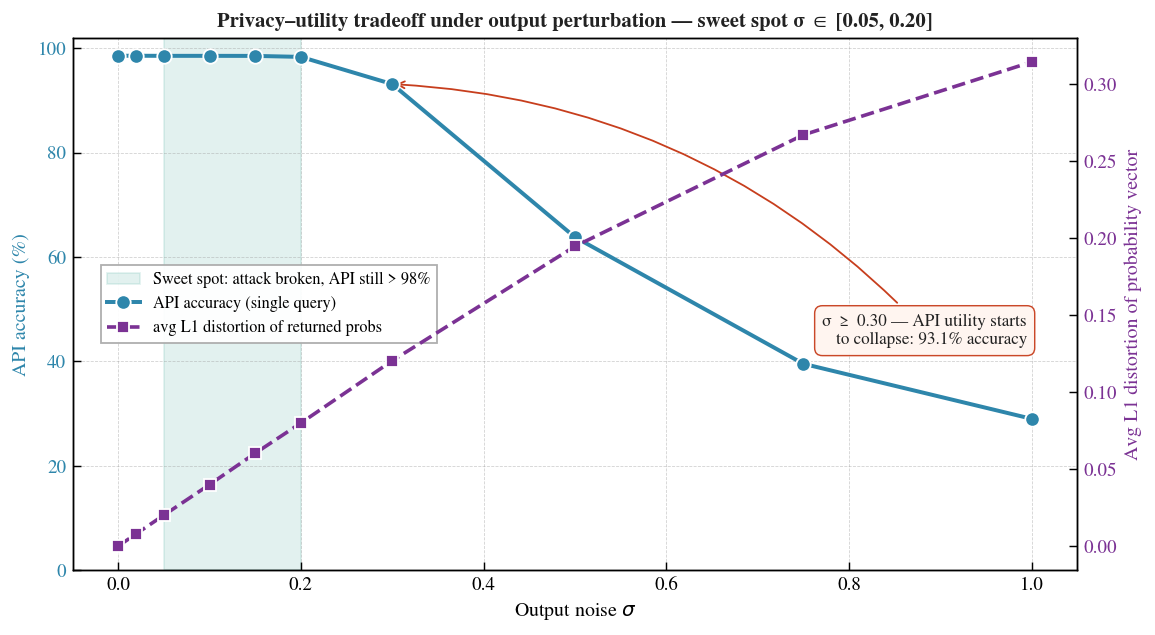

In [12]:
def api_quality_under_noise(model, loader, sigma):
    """One noisy query per input. Returns (argmax accuracy, avg L1 distortion)."""
    model.eval()
    correct, total = 0, 0
    l1_sum = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            probs = model(imgs)
            noise = torch.randn_like(probs) * sigma
            noisy = (probs + noise).clamp(0, 1)
            preds = noisy.argmax(1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
            l1_sum  += (noisy - probs).abs().mean(1).sum().item()
    return correct / total, l1_sum / total

sigmas_util = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 1.00]
print(f'{"Sigma":>6}  {"API acc":>8}  {"Acc drop":>9}  {"avg |noisy-clean|":>18}')
print('-' * 55)
baseline_acc, _ = api_quality_under_noise(digit_model, mnist_test, sigma=0.0)
util_records = []
for sigma in sigmas_util:
    acc, l1 = api_quality_under_noise(digit_model, mnist_test, sigma=sigma)
    drop = (baseline_acc - acc) * 100
    util_records.append((sigma, acc, drop, l1))
    print(f'{sigma:>6.2f}  {acc*100:>7.2f}%  {drop:>7.2f}pp  {l1:>18.4f}')

xs       = [r[0] for r in util_records]
acc_pct  = [r[1] * 100 for r in util_records]
l1_vals  = [r[3] for r in util_records]

fig, ax1 = plt.subplots(figsize=(9.0, 5.0))
ax2 = ax1.twinx()

ax1.axvspan(0.05, 0.20, color=DEFENSE_COLOR, alpha=0.15, zorder=0,
            label='Sweet spot: attack broken, API still > 98%')

ax1.plot(xs, acc_pct, 'o-', color=LOW_RISK_COLOR, lw=2.2, ms=8,
         markeredgecolor='white', markeredgewidth=1.0, zorder=4,
         label='API accuracy (single query)')
ax1.set_xlabel(r'Output noise $\sigma$')
ax1.set_ylabel('API accuracy (%)', color=LOW_RISK_COLOR)
ax1.tick_params(axis='y', labelcolor=LOW_RISK_COLOR)
ax1.set_ylim(0, 102)
_grid(ax1, 'both')

ax2.plot(xs, l1_vals, 's--', color=NOISE_COLOR, lw=2.0, ms=7,
         markeredgecolor='white', markeredgewidth=1.0, zorder=4,
         label='avg L1 distortion of returned probs')
ax2.set_ylabel('Avg L1 distortion of probability vector', color=NOISE_COLOR)
ax2.tick_params(axis='y', labelcolor=NOISE_COLOR)

cliff_idx = next((i for i, s in enumerate(xs) if s >= 0.30), len(xs) - 1)
ax1.annotate(
    f'σ ≥ 0.30 — API utility starts\nto collapse: {acc_pct[cliff_idx]:.1f}% accuracy',
    xy=(xs[cliff_idx], acc_pct[cliff_idx]),
    xytext=(0.95, 0.45), textcoords='axes fraction',
    fontsize=9.5, ha='right', va='center', color='#222222',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFF5F0',
              edgecolor=HIGH_RISK_COLOR, linewidth=0.8, alpha=0.95),
    arrowprops=dict(arrowstyle='->', color=HIGH_RISK_COLOR, lw=1.0,
                    connectionstyle='arc3,rad=0.2'))

lns = ax1.get_lines() + ax2.get_lines()
labels = [ln.get_label() for ln in lns]
sweet_patch = ax1.patches[0] if ax1.patches else None
if sweet_patch is not None:
    lns.insert(0, sweet_patch); labels.insert(0, sweet_patch.get_label())
ax1.legend(lns, labels, loc='center left', fontsize=9.0,
           framealpha=0.94, bbox_to_anchor=(0.02, 0.5))

plt.title('Privacy–utility tradeoff under output perturbation — '
          'sweet spot σ ∈ [0.05, 0.20]',
          fontsize=11.5, color='#222222', fontweight='bold')
plt.tight_layout(); plt.show()


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Nimbus Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Nimbus Roman.
  fig.canvas.print_figure(bytes_io, **kw)


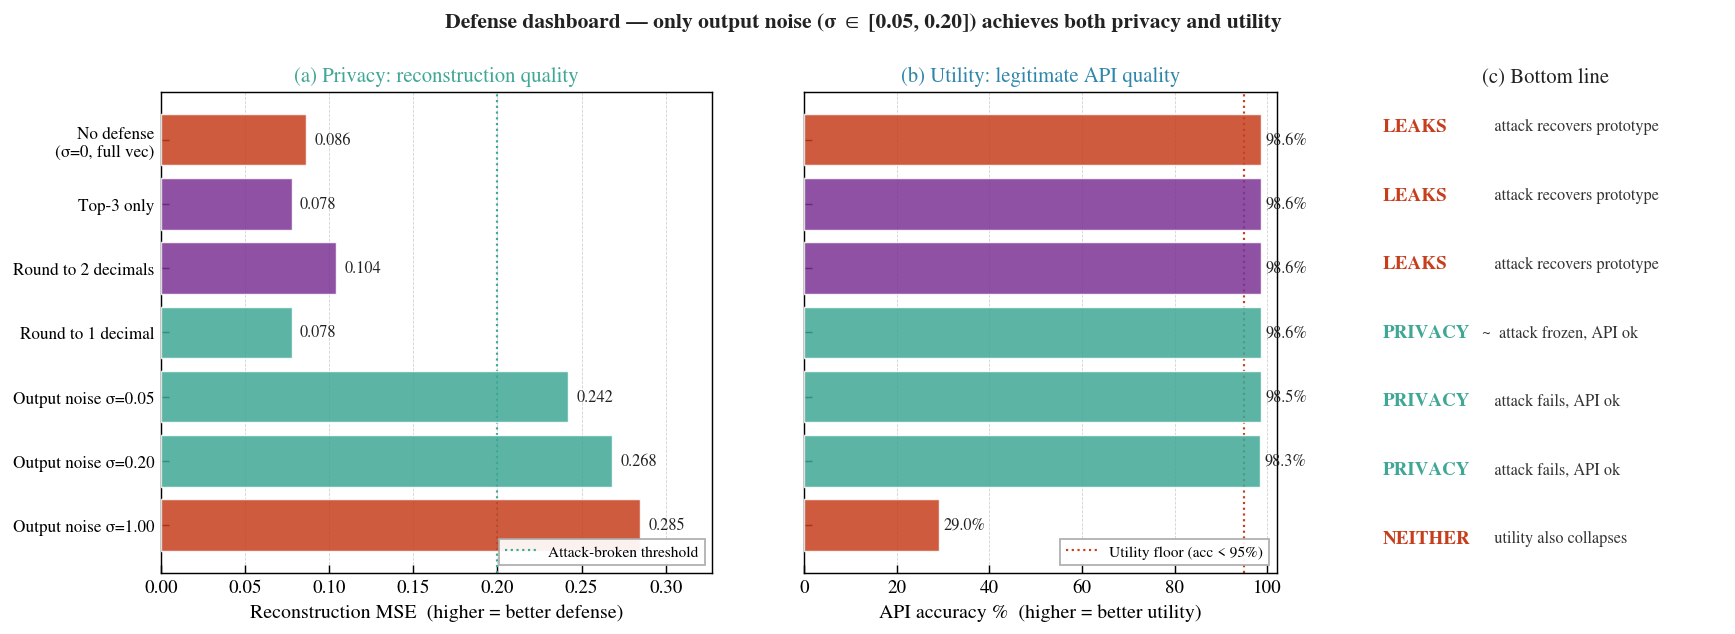

In [13]:
defenses = [
    ('No defense\n(σ=0, full vec)',    mse_by_sigma[0.00], acc_pct[0],            'leaks',   ATTACK_COLOR),
    ('Top-3 only',                       bb_mse['top3'],     acc_pct[0],            'leaks',   NOISE_COLOR),
    ('Round to 2 decimals',              bb_mse['round2'],   acc_pct[0],            'leaks',   NOISE_COLOR),
    ('Round to 1 decimal',               bb_mse['round1'],   acc_pct[0],            'frozen',  DEFENSE_COLOR),
    ('Output noise σ=0.05',              mse_by_sigma[0.05], acc_pct[xs.index(0.05)],'broken',  DEFENSE_COLOR),
    ('Output noise σ=0.20',              mse_by_sigma[0.20], acc_pct[xs.index(0.20)],'broken',  DEFENSE_COLOR),
    ('Output noise σ=1.00',              mse_by_sigma[0.50], acc_pct[xs.index(1.00)],'collapse',HIGH_RISK_COLOR),
]

names    = [d[0] for d in defenses]
mses     = [d[1] for d in defenses]
accs     = [d[2] for d in defenses]
verdicts = [d[3] for d in defenses]
colors   = [d[4] for d in defenses]

fig = plt.figure(figsize=(13.5, 5.6))
gs  = GridSpec(1, 3, width_ratios=[1.4, 1.2, 0.9],
               left=0.10, right=0.99, top=0.86, bottom=0.20, wspace=0.20)

ax = fig.add_subplot(gs[0, 0])
ypos = np.arange(len(names))
ax.barh(ypos, mses, color=colors, alpha=0.85, edgecolor='white', lw=0.8, zorder=3)
ax.axvline(0.20, color=DEFENSE_COLOR, ls=':', lw=1.2, zorder=2,
           label='Attack-broken threshold')
ax.set_yticks(ypos); ax.set_yticklabels(names, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel('Reconstruction MSE  (higher = better defense)')
ax.set_title('(a) Privacy: reconstruction quality',
             pad=6, color=DEFENSE_COLOR)
ax.set_xlim(0, max(mses)*1.15)
_grid(ax, 'x')
ax.legend(loc='lower right', fontsize=8.5)
for i, v in enumerate(mses):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, color='#222222')

ax = fig.add_subplot(gs[0, 1])
ax.barh(ypos, accs, color=colors, alpha=0.85, edgecolor='white', lw=0.8, zorder=3)
ax.axvline(95, color=HIGH_RISK_COLOR, ls=':', lw=1.2, zorder=2,
           label='Utility floor (acc < 95%)')
ax.set_yticks(ypos); ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel('API accuracy %  (higher = better utility)')
ax.set_title('(b) Utility: legitimate API quality',
             pad=6, color=LOW_RISK_COLOR)
ax.set_xlim(0, 102)
_grid(ax, 'x')
ax.legend(loc='lower right', fontsize=8.5)
for i, v in enumerate(accs):
    ax.text(v + 1.0, i, f'{v:.1f}%', va='center', fontsize=9, color='#222222')

ax = fig.add_subplot(gs[0, 2])
ax.axis('off')
verdict_map = {
    'leaks':    ('LEAKS',    HIGH_RISK_COLOR, '✗  attack recovers prototype'),
    'frozen':   ('PRIVACY',  DEFENSE_COLOR,   '~  attack frozen, API ok'),
    'broken':   ('PRIVACY',  DEFENSE_COLOR,   '✓  attack fails, API ok'),
    'collapse': ('NEITHER',  HIGH_RISK_COLOR, '✗  utility also collapses'),
}
for i, v in enumerate(verdicts):
    label, col, blurb = verdict_map[v]
    ax.text(0.04, 1 - (i + 0.5) / len(verdicts), label,
            color=col, fontsize=10.5, fontweight='bold', va='center')
    ax.text(0.32, 1 - (i + 0.5) / len(verdicts), blurb,
            color='#333333', fontsize=9.0, va='center')
ax.set_title('(c) Bottom line', pad=6, color='#222222')

plt.suptitle('Defense dashboard — '
             'only output noise (σ ∈ [0.05, 0.20]) achieves both privacy and utility',
             fontsize=12.0, y=0.97, color='#222222', fontweight='bold')
plt.show()
